<a href="https://colab.research.google.com/github/Sam-Arkle/CS5455/blob/main/fig_1_2_4_and_1_2_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

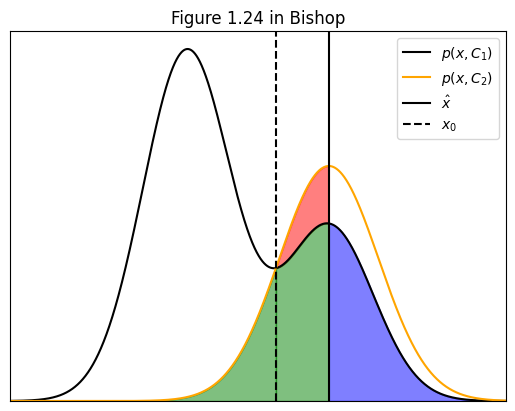

In [57]:
# Another attempt at creating the joint probabilities for the two distributions.

from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


# C1 and C2 are both classes which have normal distributions.

c1_mu = 3
c1_sd = 1.25

# We are creating a gaussian mixture model, and so we will need weights which sum to 1.
w1 = 2/3
w2= 1/3

c2_mu = 7
c2_sd = 1.4

# Probabilities of c1 and c2
c1 = 2/3
c2 = 1/3

x = np.linspace(-5, 15, 50_000)

# Creating the data points
p_x_given_c1 = w1 * norm.pdf(x, c1_mu, c1_sd) + w2 * norm.pdf(x, c2_mu, c1_sd) # Generating the data for p(x| C1)
p_x_c1 = p_x_given_c1 * c1

p_x_given_c2 = norm.pdf(x, c2_mu, c2_sd) # There is no need for a weight here, the integral should be 1
p_x_c2 = p_x_given_c2 * c2


# Finding the intersect of the two functions to determine x_0
diff_c1_c2 = p_x_c1 - p_x_c2
sign_change = np.where(np.diff(np.sign(diff_c1_c2)))[0]
x_intersect = x[sign_change]

# Plotting the graphs
plt.plot(x, p_x_c1, label='$p(x, C_1)$', color='black')
plt.plot(x, p_x_c2, label='$p(x, C_2)$', color='orange')
plt.axvline(c2_mu, color='black', label='$\hat{x}$')
plt.axvline(x_intersect, color='black', linestyle='dashed', label='$x_0$')

# Shading the graph
plt.fill_between(x, p_x_c1, where = x > c2_mu,  color='blue', alpha =0.5)
plt.fill_between(x, p_x_c1, p_x_c2, where = (x < c2_mu) & (x > x_intersect), color='red', alpha=0.5)
plt.fill_between(x, p_x_c2,  where = (p_x_c2 < p_x_c1) & (x < c2_mu), color='green', alpha=0.5)
plt.fill_between(x, p_x_c1,  where = (p_x_c1 < p_x_c2) & (x < c2_mu), color='green', alpha=0.5)


plt.xlim(left = -2, right = 12)
plt.ylim(bottom=0)
plt.yticks([])
plt.xticks([])

plt.title('Figure 1.24 in Bishop')
plt.legend()
plt.show()

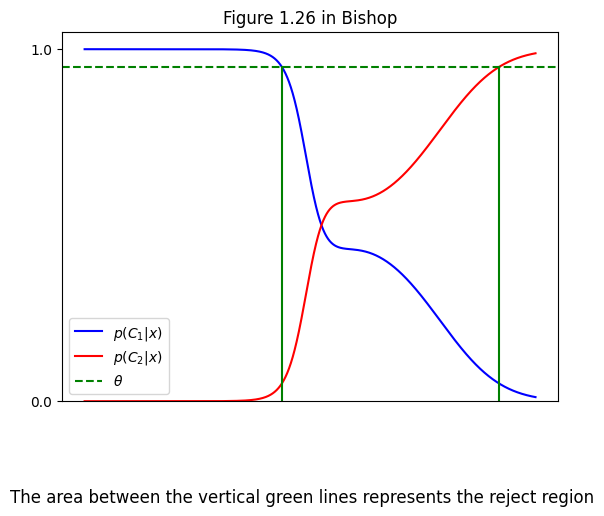

In [107]:
# Now want to generate figure 1.26 which shows the conditional probabilities and reject region
import matplotlib.ticker as mticker
#Generating the data
p_x = p_x_c1 + p_x_c2           #p(x) = p(x,c1) + p(x,c2)
p_c1_given_x = p_x_c1 / p_x     # p(c1|x) = p(x,c1)/p(x)
p_c2_given_x = p_x_c2 / p_x

# Theta is our reject threshold, unless our confidence is above theta we reject the classification
theta = 0.95

# We determine where theta intersects with our two probabilities to visualise the reject region
# A lazy way to determine the x-value for the intersect would be to plug in x-values and see which is closest to .95
c1_intersect = 0
diff = 1
for i in range(20_000,25_000): # Values determined by plugging in randomly to see where it crosses 0.95
  new_diff = abs(0.95 - p_c1_given_x[i])
  if (new_diff < diff):
    diff = new_diff
    c1_intersect = i

c2_intersect = 0
diff = 1
for i in range(45_000, 49_999):
  new_diff = abs(0.95 - p_c2_given_x[i])
  if (new_diff < diff):
    diff = new_diff
    c2_intersect = i

# Plotting the data
plt.plot(x, p_c1_given_x, label='$p(C_1|x)$', color='blue')
plt.plot(x, p_c2_given_x, label='$p(C_2|x)$', color='red')
plt.axhline(theta, color='green', label=r'$\theta$', linestyle='dashed')
plt.plot([x[c1_intersect],x[c1_intersect]], [0,0.95],  color='green')
plt.plot([x[c2_intersect],x[c2_intersect]], [0,0.95],  color='green')


plt.ylim(bottom=0)
plt.yticks([0.0,1.0])
plt.gca().yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))  # Formatting y-axis to show 1.0 instead of 1
plt.xticks([])

plt.title('Figure 1.26 in Bishop')
plt.legend()

textstr = "The area between the vertical green lines represents the reject region"
plt.figtext(0.5, -0.1, textstr, wrap=True, horizontalalignment='center', fontsize=12)

plt.show()

In [79]:
p_c2_given_x[49_000]

0.9827243259391473